In [1]:
import pandas as pd
import glob
import seaborn as sns
import tqdm
import numpy as np
import matplotlib.pyplot as plt

# Time course normalization
- Does total # UMIs captured across time change?

## Puro only

In [2]:
puro_results = glob.glob("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/TL4B2/puro_only/no_err_corr/trebl_experiment_*/*reads_per_umi.tsv")
puro_results

['/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/TL4B2/puro_only/no_err_corr/trebl_experiment_a5_ADBC_Puro_Only_R1_T4_S94/a5_ADBC_Puro_Only_R1_T4_S94_reads_per_umi.tsv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/TL4B2/puro_only/no_err_corr/trebl_experiment_r17_RTBC_Puro_Only_R1_T0_S114/r17_RTBC_Puro_Only_R1_T0_S114_reads_per_umi.tsv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/TL4B2/puro_only/no_err_corr/trebl_experiment_r19_RTBC_Puro_Only_R3_T0_S116/r19_RTBC_Puro_Only_R3_T0_S116_reads_per_umi.tsv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/TL4B2/puro_only/no_err_corr/trebl_experiment_a9_ADBC_Puro_Only_R1_T24_S98/a9_ADBC_Puro_Only_R1_T24_S98_reads_per_umi.tsv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/NKX2-2/TL4B2/puro_only/no_err_corr/trebl_experiment_r12_RTBC_Puro_Only_R4_T24_S109/r12_RTBC_Puro_Only_R4_T24_S109_reads_per

In [3]:
paths = []
total_umi_counts = []

for path in tqdm.tqdm(puro_results):
    paths.append(path)
    df = pd.read_csv(path)
    molecule_count = len(df)
    total_umi_counts.append(molecule_count)


100%|██████████| 32/32 [00:45<00:00,  1.42s/it]


In [4]:
umi_counts = pd.DataFrame({'path' : paths, 
                           'molecules' : total_umi_counts})
umi_counts

,path,molecules
0,/global/scratch/projects/fc_mvslab/OpenProject...,1108424
1,/global/scratch/projects/fc_mvslab/OpenProject...,336230
2,/global/scratch/projects/fc_mvslab/OpenProject...,307279
3,/global/scratch/projects/fc_mvslab/OpenProject...,3356137
4,/global/scratch/projects/fc_mvslab/OpenProject...,2160783
5,/global/scratch/projects/fc_mvslab/OpenProject...,289888
6,/global/scratch/projects/fc_mvslab/OpenProject...,327805
7,/global/scratch/projects/fc_mvslab/OpenProject...,1122607
8,/global/scratch/projects/fc_mvslab/OpenProject...,2633951
9,/global/scratch/projects/fc_mvslab/OpenProject...,2407794


In [5]:
umi_counts["rep"] = umi_counts["path"].str.extract("_R(\d+)_").astype(int)
umi_counts["time"] = umi_counts["path"].str.extract("_T(\d+)_").astype(int)
umi_counts["seq_type"] = umi_counts["path"].str.extract("_(..)BC_")
umi_counts

,path,molecules,rep,time,seq_type
0,/global/scratch/projects/fc_mvslab/OpenProject...,1108424,1,4,AD
1,/global/scratch/projects/fc_mvslab/OpenProject...,336230,1,0,RT
2,/global/scratch/projects/fc_mvslab/OpenProject...,307279,3,0,RT
3,/global/scratch/projects/fc_mvslab/OpenProject...,3356137,1,24,AD
4,/global/scratch/projects/fc_mvslab/OpenProject...,2160783,4,24,RT
5,/global/scratch/projects/fc_mvslab/OpenProject...,289888,2,0,RT
6,/global/scratch/projects/fc_mvslab/OpenProject...,327805,1,0,AD
7,/global/scratch/projects/fc_mvslab/OpenProject...,1122607,2,4,AD
8,/global/scratch/projects/fc_mvslab/OpenProject...,2633951,1,24,RT
9,/global/scratch/projects/fc_mvslab/OpenProject...,2407794,2,24,AD


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


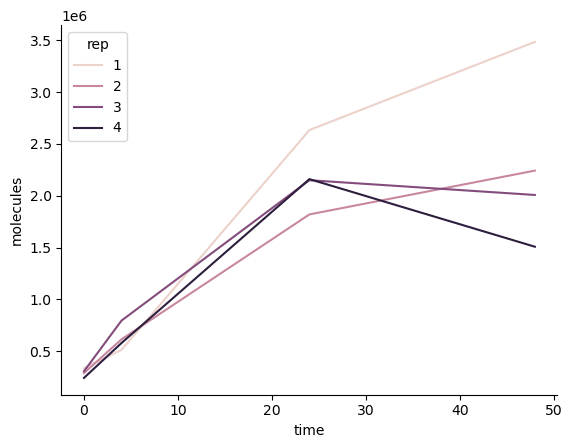

In [6]:
sns.lineplot(data = umi_counts[umi_counts["seq_type"] == "RT"], x = "time", y = "molecules", hue = "rep")
#ax = sns.scatterplot(data = umi_counts[umi_counts["seq_type"] == "RT"], x = "time", y = "molecules", hue = "rep")
sns.despine()

The total number of molecules recovered increases over time. We are not sequencing all UMIs, however, so the counts depend on the RT sequencing depth. 

In [7]:
read_counts = pd.read_csv("../../data/TL4B2_reads_per_sample_cleaned.csv")
read_counts = read_counts[read_counts["drug"] == "Puro_Only"]
#read_counts = read_counts[read_counts["seq_type"] == "AD"]
read_counts.head()

,Unnamed: 0,drug,reads,time,rep,seq_type
0,0,Puro_Only,1143881,48,1,AD
1,1,Puro_Only,1909214,0,4,RT
2,2,Puro_Only,2417417,0,2,RT
3,3,Puro_Only,2853220,0,4,AD
4,4,Puro_Only,2976628,4,1,RT


In [8]:
umi_counts_with_reads = pd.merge(umi_counts, read_counts, how = 'left')
umi_counts_with_reads

,path,molecules,rep,time,seq_type,Unnamed: 0,drug,reads
0,/global/scratch/projects/fc_mvslab/OpenProject...,1108424,1,4,AD,20,Puro_Only,6386541
1,/global/scratch/projects/fc_mvslab/OpenProject...,336230,1,0,RT,10,Puro_Only,4461888
2,/global/scratch/projects/fc_mvslab/OpenProject...,307279,3,0,RT,9,Puro_Only,4187533
3,/global/scratch/projects/fc_mvslab/OpenProject...,3356137,1,24,AD,65,Puro_Only,16833820
4,/global/scratch/projects/fc_mvslab/OpenProject...,2160783,4,24,RT,28,Puro_Only,9790956
5,/global/scratch/projects/fc_mvslab/OpenProject...,289888,2,0,RT,2,Puro_Only,2417417
6,/global/scratch/projects/fc_mvslab/OpenProject...,327805,1,0,AD,8,Puro_Only,4020231
7,/global/scratch/projects/fc_mvslab/OpenProject...,1122607,2,4,AD,26,Puro_Only,8879588
8,/global/scratch/projects/fc_mvslab/OpenProject...,2633951,1,24,RT,62,Puro_Only,16320819
9,/global/scratch/projects/fc_mvslab/OpenProject...,2407794,2,24,AD,23,Puro_Only,7082110


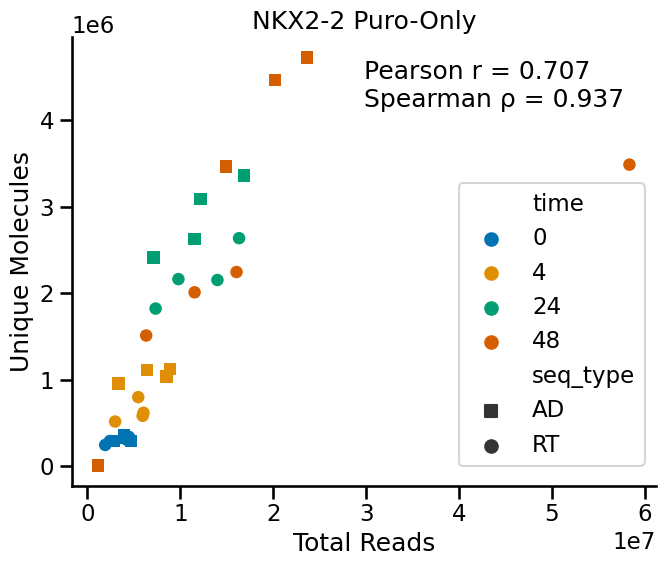

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# drop missing values
#df = umi_counts_with_reads[umi_counts_with_reads["seq_type"] == "RT"]
df = umi_counts_with_reads.dropna()

# correlations on raw data
pearson_r, pearson_p = pearsonr(df["reads"], df["molecules"])
spearman_r, spearman_p = spearmanr(df["reads"], df["molecules"])

# plot
fig, ax = plt.subplots(figsize=(7,6))

sns.scatterplot(
    data=df,
    x="reads",
    y="molecules",
    hue="time",
    style="seq_type",
    markers={"RT": "o", "AD": "s"},   # <-- choose shapes
    palette="colorblind",
    edgecolor="none",
    ax=ax
)

sns.despine()

# annotate
ax.text(
    0.5, 0.95,
    (
        f"Pearson r = {pearson_r:.3f}\n"
        f"Spearman ρ = {spearman_r:.3f}\n"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top"
)

plt.legend(loc = 'upper right', bbox_to_anchor = (1,0.7))
ax.set_title("NKX2-2 Puro-Only")
plt.xlabel("Total Reads")
plt.ylabel("Unique Molecules")
plt.tight_layout()
plt.show()

# Divide by total number of reads?

In [10]:
activity_scores_raw = pd.read_csv("../../output/NKX2-2/TL4B2/puro_only/no_err_corr/unaggregated_activities.csv")
activity_scores_raw

,ADBC2,HawkBCs,RTBC,AD,time,rep,AD_umi_count_simple,RTBC_umi_count_simple,activity
0,AAAAAA,ATTCTCGCC,CTGGAATGACATAGGG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,0,1,0.0,1.0,inf
1,AAAAAA,ATTCTCGCC,CTGGAATGACATAGGG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,0,2,113.0,113.0,1.000000
2,AAAAAA,ATTCTCGCC,CTGGAATGACATAGGG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,0,3,2.0,24.0,12.000000
3,AAAAAA,ATTCTCGCC,CTGGAATGACATAGGG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,4,1,0.0,1.0,inf
4,AAAAAA,ATTCTCGCC,CTGGAATGACATAGGG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,4,2,174.0,212.0,1.218391
...,...,...,...,...,...,...,...,...,...
17444,TTTTTT,AGAGGAGTT,GGATCGTAGGTGCATG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,24,4,4996.0,4827.0,0.966173
17445,TTTTTT,AGAGGAGTT,GGATCGTAGGTGCATG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,48,1,2.0,1692.0,846.000000
17446,TTTTTT,AGAGGAGTT,GGATCGTAGGTGCATG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,48,2,9995.0,5208.0,0.521061
17447,TTTTTT,AGAGGAGTT,GGATCGTAGGTGCATG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,48,3,3724.0,3170.0,0.851235


In [11]:
umi_counts_with_reads_pivot = pd.pivot(umi_counts_with_reads, index = ["time", "rep"], values = ["reads"], columns = ["seq_type"])
umi_counts_with_reads_pivot = umi_counts_with_reads_pivot.reset_index()
umi_counts_with_reads_pivot.columns = ["time", "rep", "AD_total_umis", "RT_total_umis"]
umi_counts_with_reads_pivot

,time,rep,AD_total_umis,RT_total_umis
0,0,1,4020231,4461888
1,0,2,3948786,2417417
2,0,3,4699909,4187533
3,0,4,2853220,1909214
4,4,1,6386541,2976628
5,4,2,8879588,6028508
6,4,3,8521024,5465830
7,4,4,3346417,5937155
8,24,1,16833820,16320819
9,24,2,7082110,7334087


In [33]:
activity_scores_merged = pd.merge(activity_scores_raw, umi_counts_with_reads_pivot)
activity_scores_merged["AD_ratio"] = activity_scores_merged["AD_umi_count_simple"] / activity_scores_merged["AD_total_umis"] + 1 / activity_scores_merged["AD_total_umis"]
activity_scores_merged["RT_ratio"] = activity_scores_merged["RTBC_umi_count_simple"] / activity_scores_merged["RT_total_umis"] + 1 / activity_scores_merged["RT_total_umis"]
activity_scores_merged["activity_recalc"] = np.log(activity_scores_merged["RT_ratio"] / activity_scores_merged["AD_ratio"])
activity_scores_merged

,ADBC2,HawkBCs,RTBC,AD,time,rep,AD_umi_count_simple,RTBC_umi_count_simple,activity,AD_total_umis,RT_total_umis,AD_ratio,RT_ratio,activity_recalc
0,AAAAAA,ATTCTCGCC,CTGGAATGACATAGGG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCG...,0,1,0.0,1.0,inf,4020231,4461888,2.487419e-07,4.482407e-07,0.588915
1,AAAAAT,CATCTTAGG,TATCTCTAATAAAGTA,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,0,1,1217.0,319.0,0.262120,4020231,4461888,3.029677e-04,7.171852e-05,-1.440877
2,AAAACC,AAGCTGCGA,AGTAATATAAGGGTAA,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,0,1,4.0,55.0,13.750000,4020231,4461888,1.243710e-06,1.255074e-05,2.311681
3,AAAACC,ACCTATCAC,GATTATTGGTGCTATG,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,0,1,0.0,2.0,inf,4020231,4461888,2.487419e-07,6.723611e-07,0.994380
4,AAAACC,ATGCTCAGT,ATAACTATCCTCCGCC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,0,1,0.0,1.0,inf,4020231,4461888,2.487419e-07,4.482407e-07,0.588915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17444,TTTGGT,CCAGCTAAT,TTAGCGTTGAAAAGGC,AGCACCGCTCCTCCCACCGACGTGAGCCTGGGCGACGAGCTGCACC...,24,1,4.0,1160.0,290.000000,16833820,16320819,2.970211e-07,7.113614e-05,5.478547
17445,TTTGTT,ACCAAGATC,ATAAAAAGTAGTACTC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,24,1,1244.0,1537.0,1.235531,16833820,16320819,7.395826e-05,9.423547e-05,0.242296
17446,TTTTGC,AGCACAGGA,GAGACAGATGAATTGG,TTCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,24,1,438.0,189.0,0.431507,16833820,16320819,2.607845e-05,1.164157e-05,-0.806527
17447,TTTTGC,ATACCGTCG,AAATCGTAGACGTTAC,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATCAGCTTCA...,24,1,4393.0,3807.0,0.866606,16833820,16320819,2.610222e-04,2.333216e-04,-0.112187


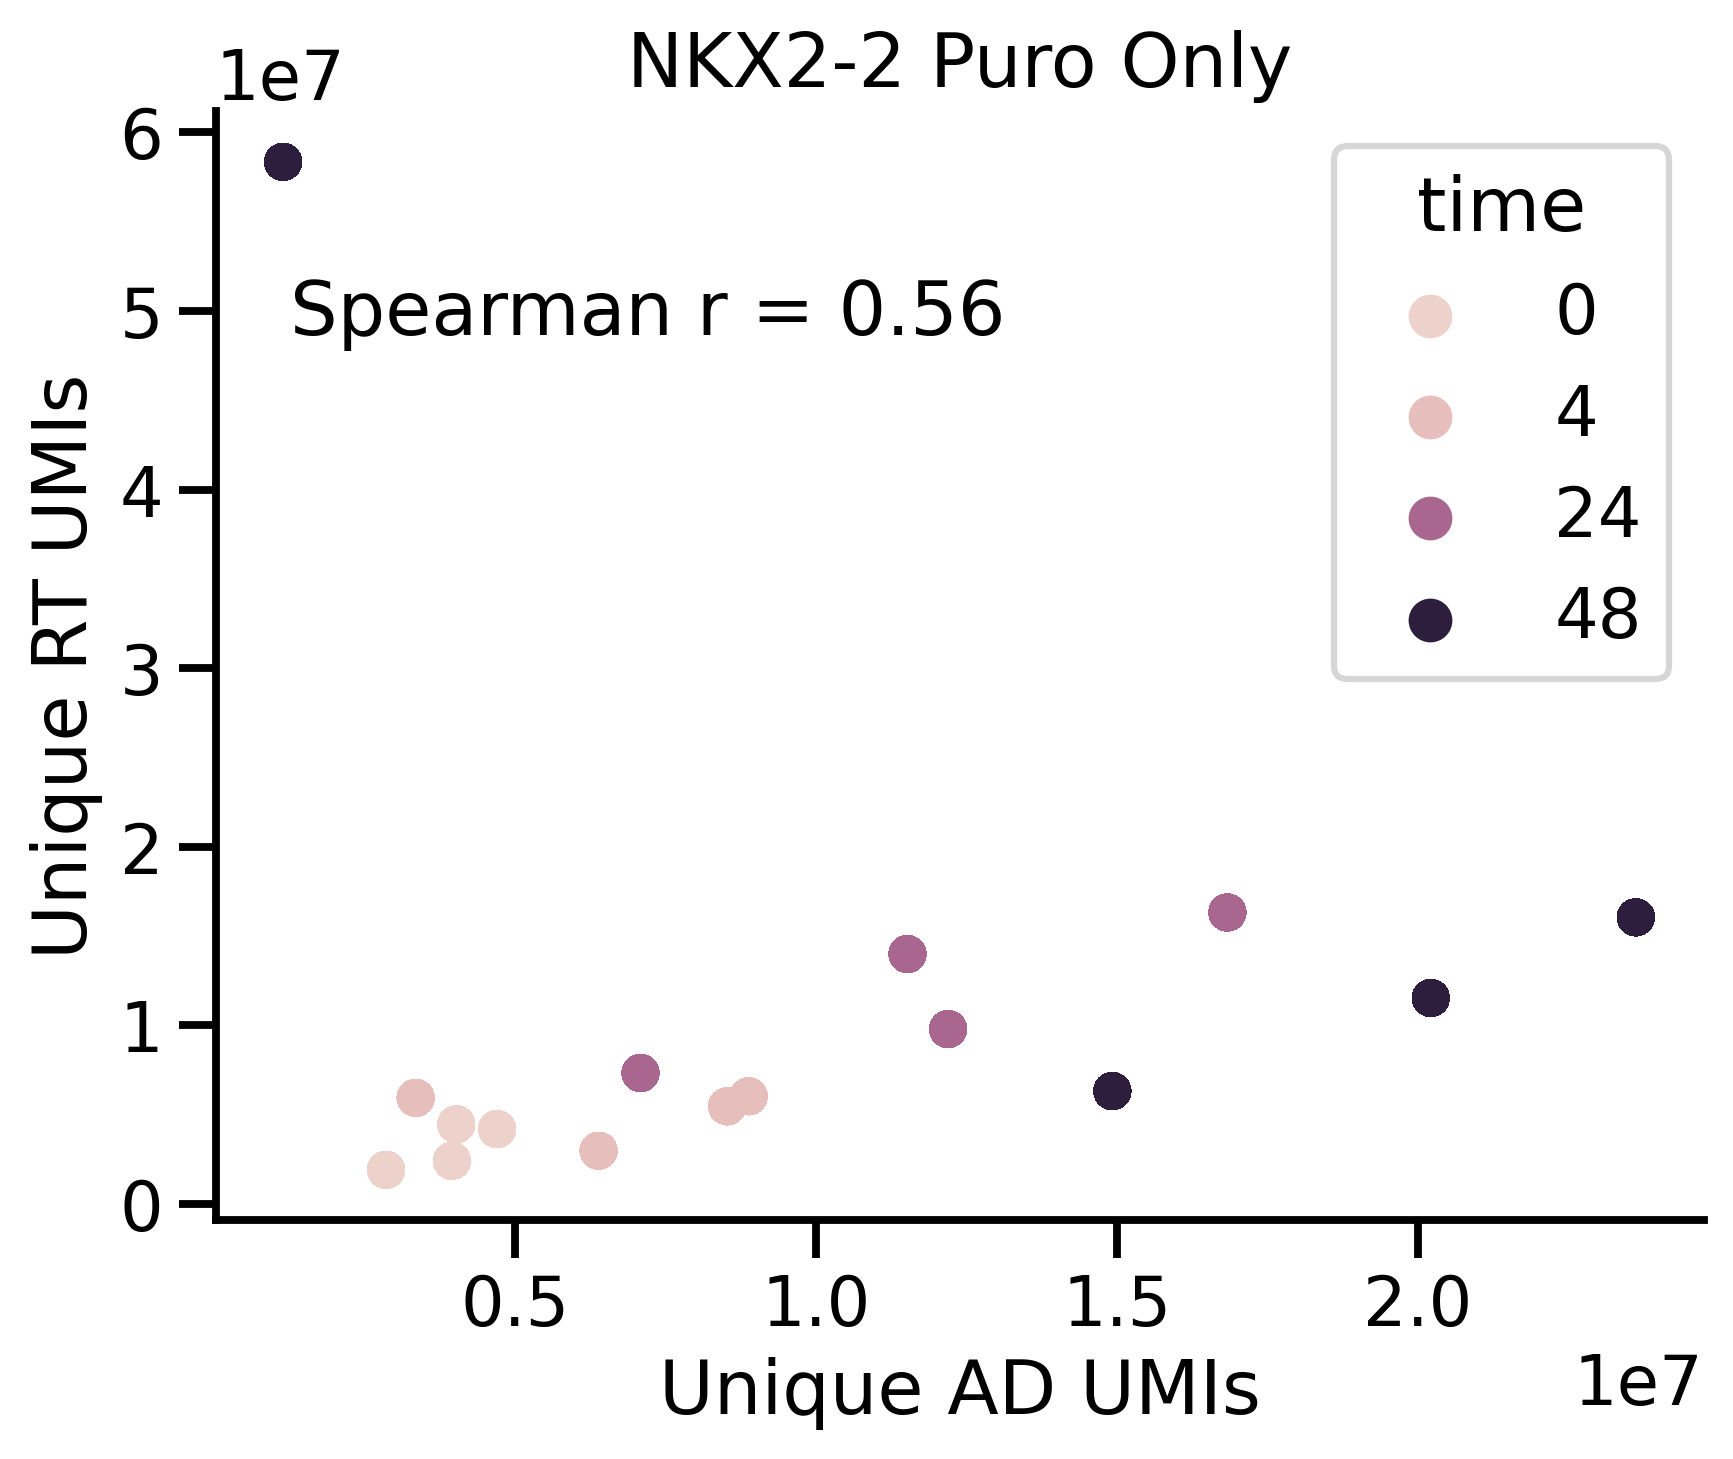

In [64]:
from scipy.stats import spearmanr

# Compute correlation
r, p = spearmanr(
    activity_scores_merged["AD_total_umis"],
    activity_scores_merged["RT_total_umis"]
)

plt.figure(dpi=300)
sns.scatterplot(
    data=activity_scores_merged,
    x="AD_total_umis",
    y="RT_total_umis",
    edgecolor="none",
    hue="time"
)
sns.despine()
plt.ylabel("Unique RT UMIs")
plt.xlabel("Unique AD UMIs")
plt.title("NKX2-2 Puro Only")

# Add correlation text (top-left corner)
plt.text(
    0.05, 0.85,
    f"Spearman r = {r:.2f}",
    transform=plt.gca().transAxes,
    ha="left",
    va="top"
)

plt.show()

/tmp/ipykernel_200948/3892280088.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sc1 = sns.scatterplot(


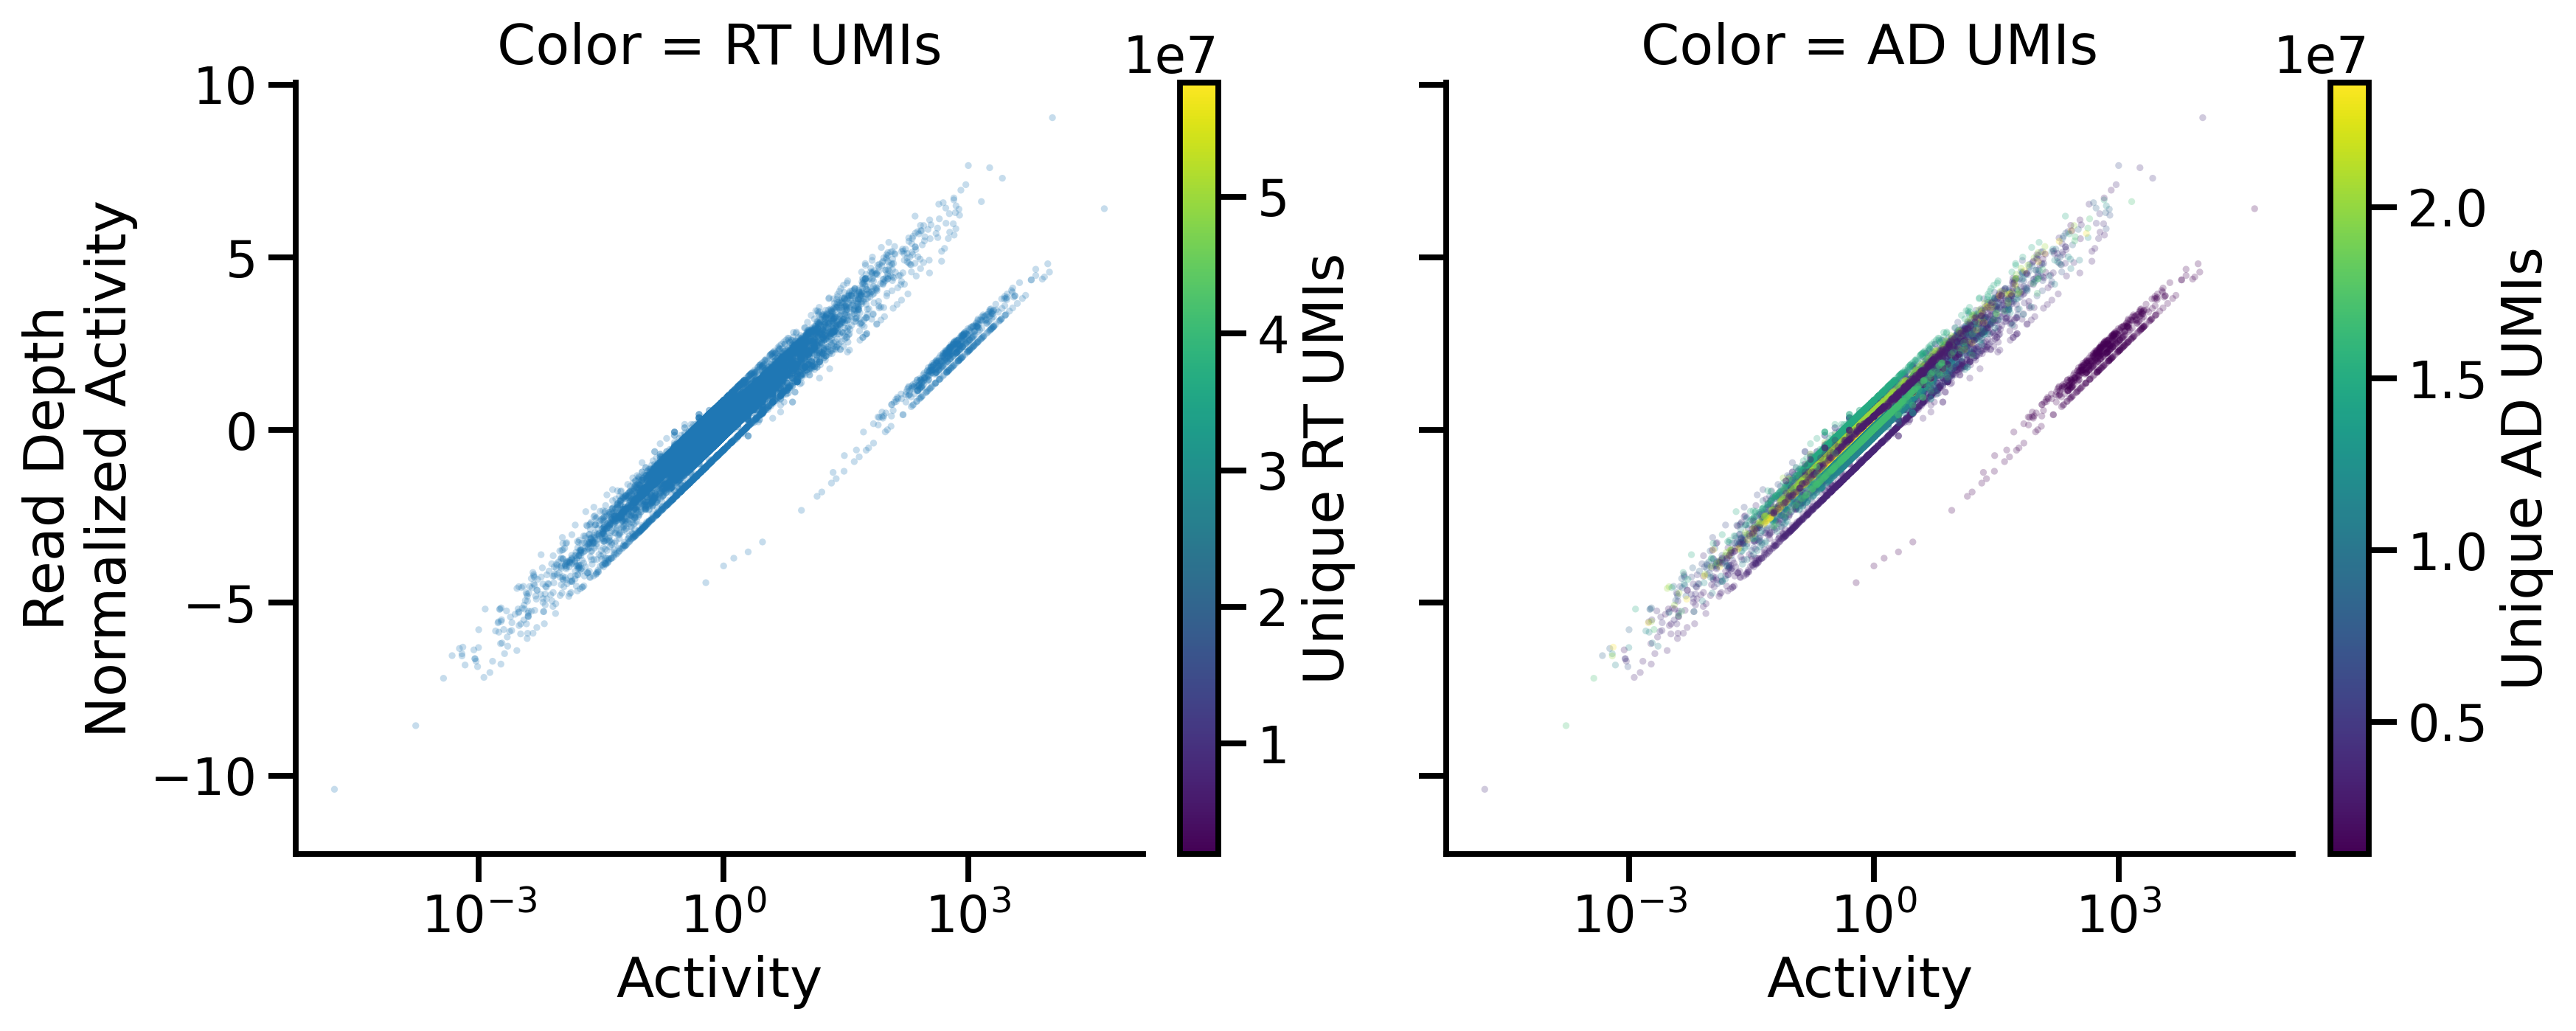

In [82]:
import matplotlib as mpl

fig, axes = plt.subplots(1, 2, figsize=(12,5), dpi=300, sharex=True, sharey=True)

# ---------- Common limits ----------
xmin = activity_scores_merged[["activity", "activity_recalc"]].min().min()
xmax = activity_scores_merged[["activity", "activity_recalc"]].max().max()
lims = (xmin, xmax)

# ---------- Panel 1: color = RT UMIs ----------
ax = axes[0]
sc1 = sns.scatterplot(
    data=activity_scores_merged,
    x="activity",
    y="activity_recalc",
    edgecolor="none",
    alpha=0.25,
    s=5,
    ax=ax,
    palette="viridis",
    legend=False
)

ax.set_xscale("log")
ax.plot(lims, lims, "--", color="black", linewidth=1)
ax.set_title("Color = RT UMIs")
ax.set_xlabel("Activity")
ax.set_ylabel("Read Depth\nNormalized Activity")
sns.despine(ax=ax)

# Colorbar (RT)
norm1 = mpl.colors.Normalize(
    vmin=activity_scores_merged["RT_total_umis"].min(),
    vmax=activity_scores_merged["RT_total_umis"].max()
)
sm1 = mpl.cm.ScalarMappable(norm=norm1, cmap="viridis")
cbar1 = fig.colorbar(sm1, ax=ax, fraction=0.046, pad=0.04)
cbar1.set_label("Unique RT UMIs")

# ---------- Panel 2: color = AD UMIs ----------
ax = axes[1]
sc2 = sns.scatterplot(
    data=activity_scores_merged,
    x="activity",
    y="activity_recalc",
    hue="AD_total_umis",
    edgecolor="none",
    alpha=0.25,
    s=5,
    ax=ax,
    palette="viridis",
    legend=False
)

ax.set_xscale("log")
ax.plot(lims, lims, "--", color="black", linewidth=1)
ax.set_title("Color = AD UMIs")
ax.set_xlabel("Activity")
sns.despine(ax=ax)


# Colorbar (AD)
norm2 = mpl.colors.Normalize(
    vmin=activity_scores_merged["AD_total_umis"].min(),
    vmax=activity_scores_merged["AD_total_umis"].max()
)
sm2 = mpl.cm.ScalarMappable(norm=norm2, cmap="viridis")
cbar2 = fig.colorbar(sm2, ax=ax, fraction=0.046, pad=0.04)
cbar2.set_label("Unique AD UMIs")

plt.tight_layout()
plt.show()

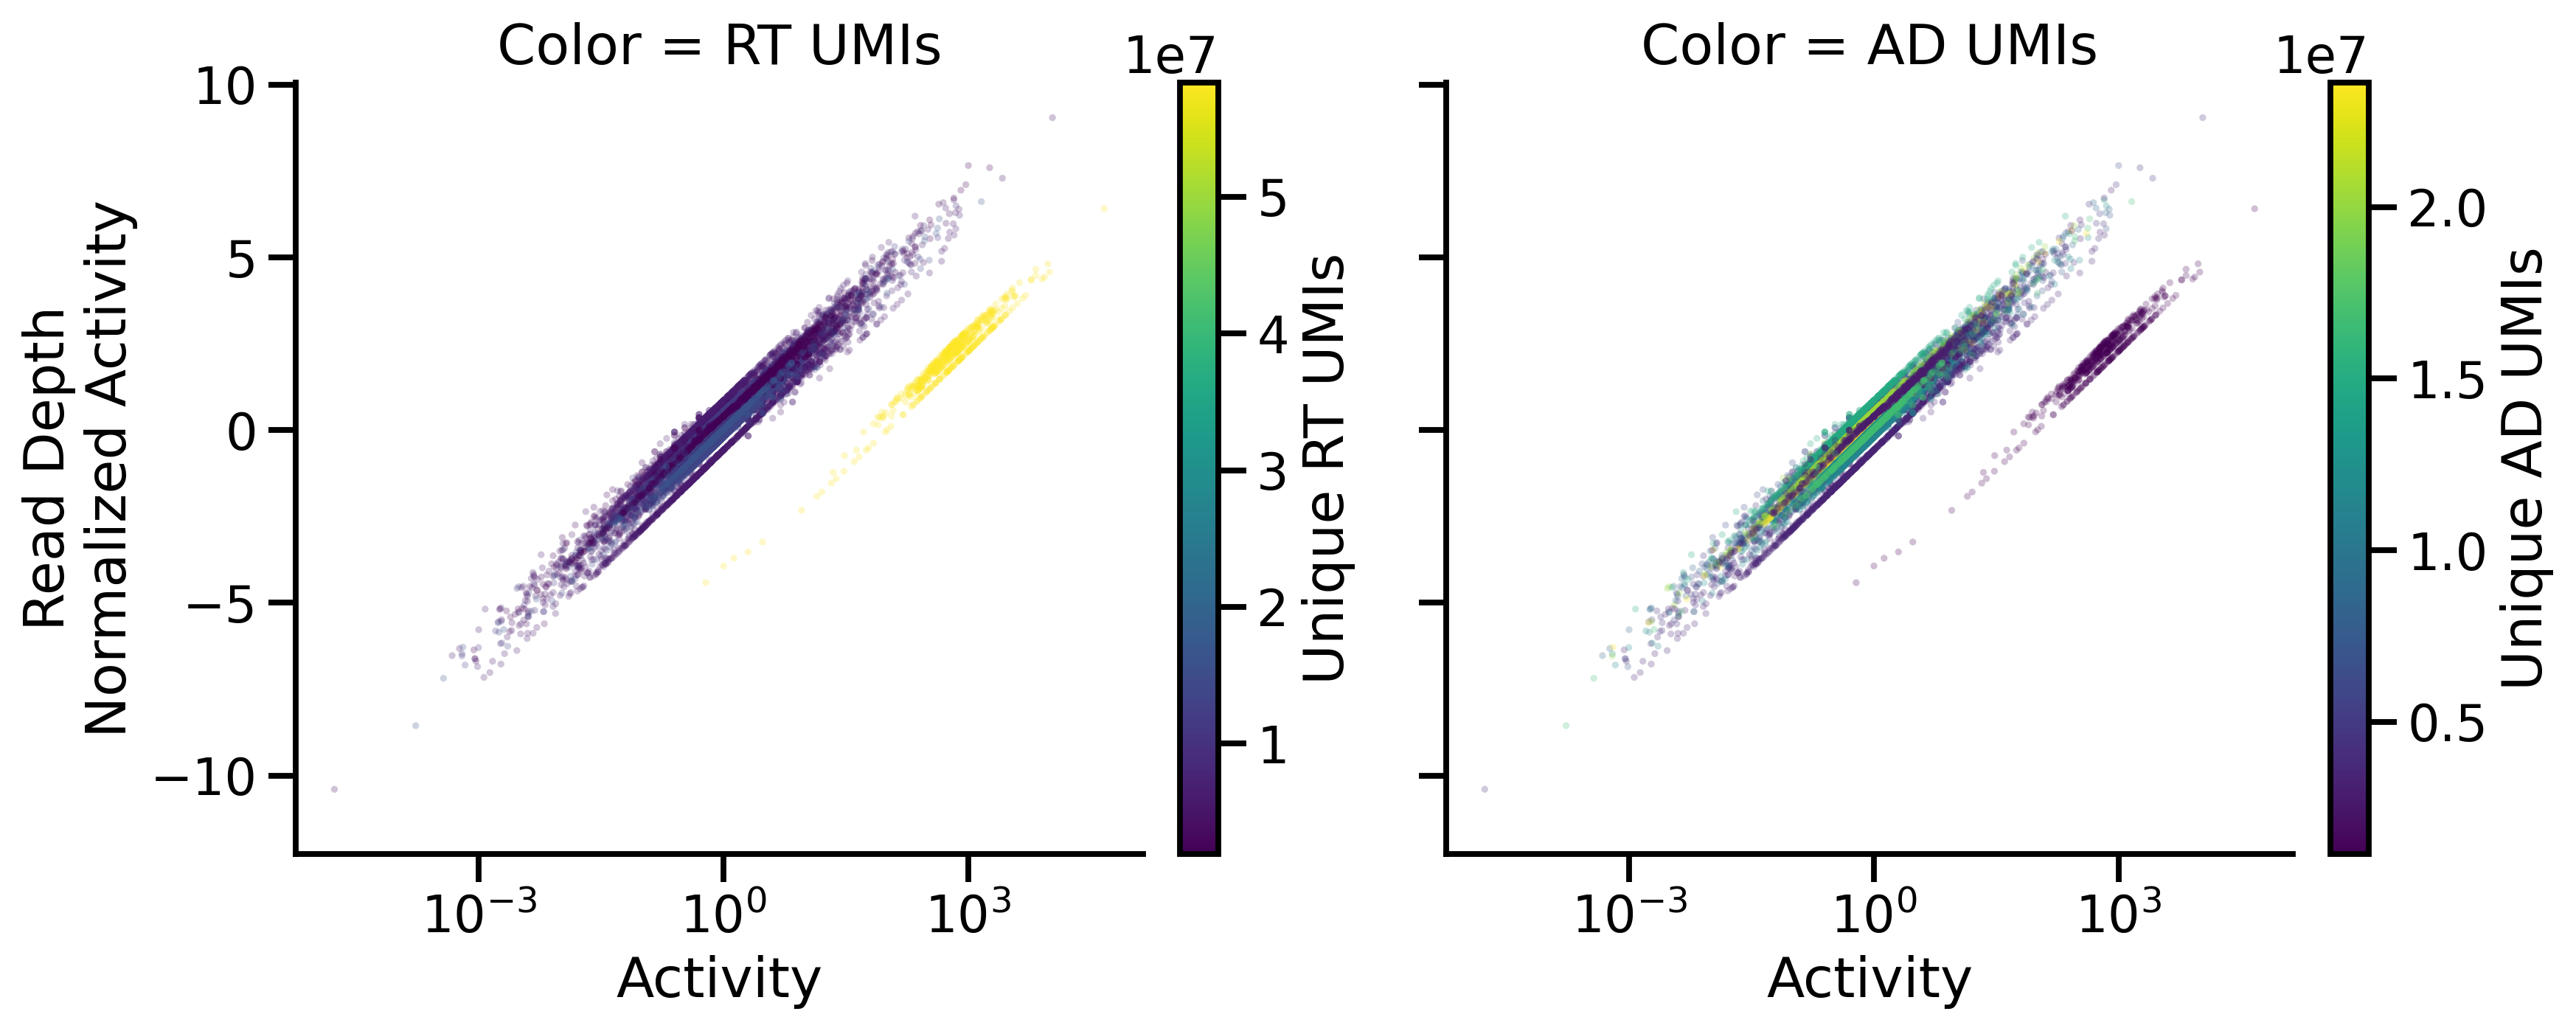

In [81]:
import matplotlib as mpl

fig, axes = plt.subplots(1, 2, figsize=(12,5), dpi=300, sharex=True, sharey=True)

# ---------- Common limits ----------
xmin = activity_scores_merged[["activity", "activity_recalc"]].min().min()
xmax = activity_scores_merged[["activity", "activity_recalc"]].max().max()
lims = (xmin, xmax)

# ---------- Panel 1: color = RT UMIs ----------
ax = axes[0]
sc1 = sns.scatterplot(
    data=activity_scores_merged,
    x="activity",
    y="activity_recalc",
    hue="RT_total_umis",
    edgecolor="none",
    alpha=0.25,
    s=5,
    ax=ax,
    palette="viridis",
    legend=False
)

ax.set_xscale("log")
ax.plot(lims, lims, "--", color="black", linewidth=1)
ax.set_title("Color = RT UMIs")
ax.set_xlabel("Activity")
ax.set_ylabel("Read Depth\nNormalized Activity")
sns.despine(ax=ax)

# Colorbar (RT)
norm1 = mpl.colors.Normalize(
    vmin=activity_scores_merged["RT_total_umis"].min(),
    vmax=activity_scores_merged["RT_total_umis"].max()
)
sm1 = mpl.cm.ScalarMappable(norm=norm1, cmap="viridis")
cbar1 = fig.colorbar(sm1, ax=ax, fraction=0.046, pad=0.04)
cbar1.set_label("Unique RT UMIs")

# ---------- Panel 2: color = AD UMIs ----------
ax = axes[1]
sc2 = sns.scatterplot(
    data=activity_scores_merged,
    x="activity",
    y="activity_recalc",
    hue="AD_total_umis",
    edgecolor="none",
    alpha=0.25,
    s=5,
    ax=ax,
    palette="viridis",
    legend=False
)

ax.set_xscale("log")
ax.plot(lims, lims, "--", color="black", linewidth=1)
ax.set_title("Color = AD UMIs")
ax.set_xlabel("Activity")
sns.despine(ax=ax)


# Colorbar (AD)
norm2 = mpl.colors.Normalize(
    vmin=activity_scores_merged["AD_total_umis"].min(),
    vmax=activity_scores_merged["AD_total_umis"].max()
)
sm2 = mpl.cm.ScalarMappable(norm=norm2, cmap="viridis")
cbar2 = fig.colorbar(sm2, ax=ax, fraction=0.046, pad=0.04)
cbar2.set_label("Unique AD UMIs")

plt.tight_layout()
plt.show()

In [37]:
activity_per_AD = activity_scores_merged[["AD", "rep", "time", "activity", "activity_recalc"]].groupby(["AD", "rep", "time"]).agg([np.mean, np.std]).reset_index()
activity_per_AD.columns = ["AD", "rep", "time", "activity_mean", "activity_std", "activity_recalc_mean", "activity_recalc_std"]
activity_per_AD

/tmp/ipykernel_200948/3551920387.py:1: FutureWarning: The provided callable <function mean at 0x155486ba4180> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  activity_per_AD = activity_scores_merged[["AD", "rep", "time", "activity", "activity_recalc"]].groupby(["AD", "rep", "time"]).agg([np.mean, np.std]).reset_index()
/tmp/ipykernel_200948/3551920387.py:1: FutureWarning: The provided callable <function std at 0x155486ba42c0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  activity_per_AD = activity_scores_merged[["AD", "rep", "time", "activity", "activity_recalc"]].groupby(["AD", "rep", "time"]).agg([np.mean, np.std]).reset_index()
/tmp/ipykernel_200948/3551920387.py:1: FutureWarning: The provided callable <function mean at 0x155486ba4180>

,AD,rep,time,activity_mean,activity_std,activity_recalc_mean,activity_recalc_std
0,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,1,24,inf,NaN,3.326785,NaN
1,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,2,0,inf,NaN,3.055658,NaN
2,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,2,4,0.215686,NaN,-1.111979,NaN
3,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,2,24,0.460526,NaN,-0.805244,NaN
4,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,2,48,0.322388,NaN,-0.739247,NaN
...,...,...,...,...,...,...,...
3493,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,3,48,inf,NaN,-0.422353,1.831847
3494,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,4,0,inf,NaN,1.257677,1.249630
3495,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,4,4,inf,NaN,-0.048700,3.388254
3496,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,4,24,5.255118,9.293139,1.032101,1.073601


In [15]:
recalc_activity_per_AD = pd.pivot(activity_per_AD, columns = ["time"], index = ["AD", "rep"], values = ["activity_recalc_mean"]).reset_index()
recalc_activity_per_AD.columns = ["AD", "rep", 0,4,24,48]
recalc_activity_per_AD

,AD,rep,0,4,24,48
0,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,1,NaN,NaN,3.326785,NaN
1,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,2,3.055658,-1.111979,-0.805244,-0.739247
2,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,3,NaN,0.239226,-0.289844,-0.825023
3,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,4,NaN,-0.285658,-1.275333,0.644086
4,ACCGACTTCATCGACGAGGAGGTGATCATGAGCATCGTGATCGAGA...,1,-0.727201,-1.443386,-0.544752,0.640878
...,...,...,...,...,...,...
892,TTCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,4,0.476853,-0.285407,1.261366,1.005459
893,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,1,1.199015,0.280546,0.204167,0.959331
894,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,2,1.023100,0.927583,1.207527,1.306154
895,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,3,1.051185,0.712485,0.347598,-0.422353


In [16]:
old_activity_per_AD = pd.pivot(activity_per_AD, columns = ["time"], index = ["AD", "rep"], values = ["activity_mean"]).reset_index()
old_activity_per_AD.columns = ["AD", "rep", 0,4,24,48]
old_activity_per_AD

,AD,rep,0,4,24,48
0,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,1,NaN,NaN,inf,NaN
1,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,2,inf,0.215686,0.460526,0.322388
2,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,3,NaN,0.807692,0.900000,0.000000
3,ACCGACGCCATCGACGAGGAGGTGGCCATGAGCGCCGTGATCGAGA...,4,NaN,1.363636,0.216981,0.800000
4,ACCGACTTCATCGACGAGGAGGTGATCATGAGCATCGTGATCGAGA...,1,6.513889,0.209914,0.799833,inf
...,...,...,...,...,...,...
892,TTCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,4,inf,inf,inf,inf
893,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,1,inf,inf,1.230835,inf
894,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,2,inf,inf,inf,inf
895,TTCGCCGACGCCACCCAGGCCGCCCTGCAGGCCGGCATTCCCTTCA...,3,inf,inf,inf,inf


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")

# sample 10 unique ADs
sampled_ads = (
    recalc_activity_per_AD["AD"]
    .dropna()
    .drop_duplicates()
    .sample(n=5, random_state=0)
)

df_sample = recalc_activity_per_AD[recalc_activity_per_AD["AD"].isin(sampled_ads)]
df_sample

,AD,rep,0,4,24,48
478,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,1,0.588915,0.475720,-0.240985,-0.887554
479,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,2,6.031972,-0.300083,-0.393715,-0.528746
480,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,3,2.255498,-2.794496,0.170926,0.338128
481,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,4,-0.108820,2.981600,0.517595,0.499407
546,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,1,0.088993,-1.379798,-1.588532,1.258187
547,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,2,-0.497154,-1.620932,-1.697712,-1.802872
548,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,3,-0.012710,-1.130566,-1.761091,-1.716828
549,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,4,-0.120284,-1.882116,-1.419512,-1.241290
554,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,1,0.591983,0.017393,-0.049021,0.620089
555,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,2,1.692906,0.012950,0.041884,-0.208385


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("talk")

df = activity_per_AD

# sample 5 unique ADs
sampled_ads = (
    df["AD"]
    .dropna()
    .drop_duplicates()
    .sample(n=5, random_state=0)
)

df_plot = df[df["AD"].isin(sampled_ads)].copy()

df_plot = df_plot.dropna(subset=["activity_recalc_mean"])

df_plot["time"] = pd.Categorical(
    df_plot["time"],
    categories=[0, 4, 24, 48],
    ordered=True
)

df_plot = df_plot[df_plot["time"].isin([4,24])]
df_plot

,AD,rep,time,activity_mean,activity_std,activity_recalc_mean,activity_recalc_std
1863,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,1,4,0.666667,NaN,0.475720,NaN
1864,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,1,24,0.750000,NaN,-0.240985,NaN
1867,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,2,4,0.501946,NaN,-0.300083,NaN
1868,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,2,24,0.698377,NaN,-0.393715,NaN
1871,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,3,4,0.225225,0.318517,-2.794496,3.467430
1872,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,3,24,1.454545,NaN,0.170926,NaN
1875,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,4,4,inf,NaN,2.981600,2.574348
1876,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,4,24,inf,NaN,0.517595,0.346715
2128,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,1,4,0.360566,0.321983,-1.379798,2.845627
2129,GCCCAGGACCTGGCCGCCGCCACCTTCCAGGCCGGCATTCCCTTCA...,1,24,0.805615,0.489123,-1.588532,3.785439


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.

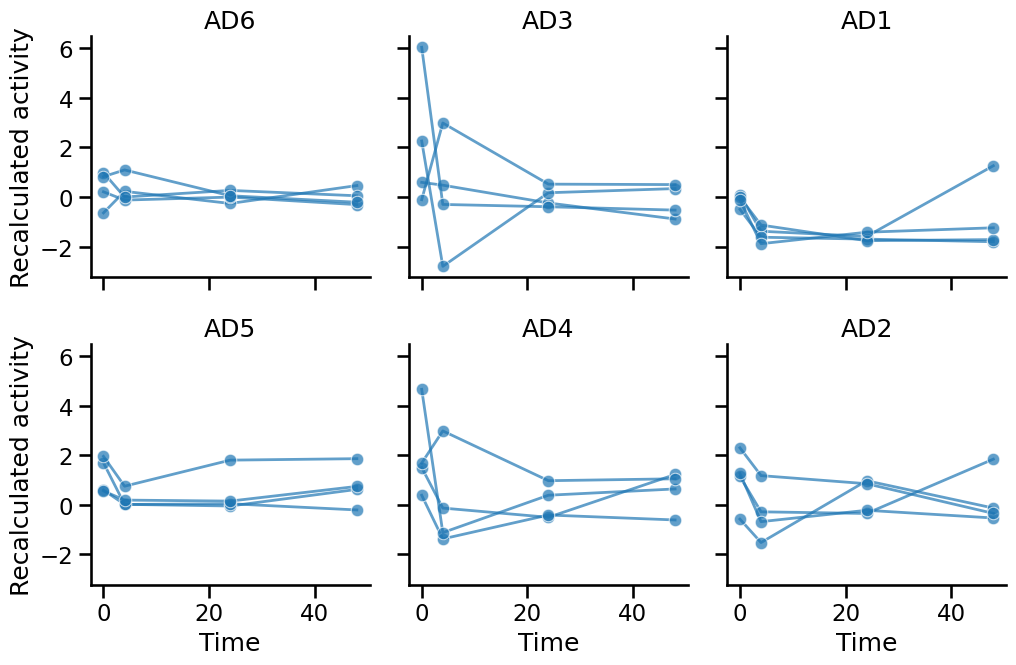

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("talk")

# -----------------------------
# INPUT: long-format dataframe
# columns must include:
# AD, rep, time, activity_recalc_mean
# -----------------------------

# sample 5 unique ADs
sampled_ads = (
    df["AD"]
    .dropna()
    .drop_duplicates()
    .sample(n=6, random_state=0)
)

# subset to sampled ADs
df_plot = df[df["AD"].isin(sampled_ads)].copy()

# clean invalid values
df_plot = df_plot.replace([float("inf"), -float("inf")], pd.NA)
df_plot = df_plot.dropna(subset=["activity_recalc_mean"])

# ensure correct time ordering
df_plot["time"] = pd.Categorical(
    df_plot["time"],
    categories=[0, 4, 24, 48],
    ordered=True
)

# optional: shorter AD labels for subplot titles
ad_map = {ad: f"AD{i+1}" for i, ad in enumerate(sampled_ads)}
df_plot["AD_label"] = df_plot["AD"].map(ad_map)

# -----------------------------
# FACETED PLOT: one AD per subplot
# -----------------------------

g = sns.FacetGrid(
    df_plot,
    col="AD_label",
    col_wrap=3,
    sharey=True,
    height=3.5
)

g.map_dataframe(
    sns.lineplot,
    x="time",
    y="activity_recalc_mean",
    units="rep",        # one line per replicate
    estimator=None,     # do NOT average
    marker="o",
    linewidth=2,
    alpha=0.7
)

g.set_axis_labels("Time", "Recalculated activity")
g.set_titles("{col_name}")
sns.despine()

plt.tight_layout()
plt.show()